In [1]:
import numpy as np
import sympy as sp
from full_ddegp.ddegp import ddegp
import utils
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 16
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50

# Global set of directional rays
rays = np.array([
    [np.cos(np.pi/4), np.cos(np.pi/2), np.cos(3*np.pi/4)],
    [np.sin(np.pi/4), np.sin(np.pi/2), np.sin(3*np.pi/4)]
])

normalize_data = True
kernel = "RQ"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
random_seed = 1
np.random.seed(random_seed)

In [3]:
def branin_function(X, alg=np):
    """2D Branin function - a common benchmark for optimization."""
    x1, x2 = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4.0*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8.0*np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*alg.cos(x1) + s

# Define symbolic version for derivatives
x1_sym, x2_sym = sp.symbols('x1 x2')
a, b, c, r, s, t = 1.0, 5.1/(4.0*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8.0*sp.pi)
f_sym = a * (x2_sym - b*x1_sym**2 + c*x1_sym - r)**2 + s*(1 - t)*sp.cos(x1_sym) + s

# Compute gradients symbolically
grad_x1 = sp.diff(f_sym, x1_sym)
grad_x2 = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
f_func = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2, 'numpy')

In [4]:
def generate_training_data():
    """Generate training data with LHS and compute directional derivatives using SymPy."""
    # Latin Hypercube Sampling for training points
    sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
    unit_samples = sampler.random(n=num_training_pts)
    X_train = qmc.scale(unit_samples, [b[0] for b in domain_bounds], [b[1] for b in domain_bounds])

    # Compute function values
    y_func = f_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

    # Compute coordinate-aligned gradients
    grad_x1_vals = grad_x1_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)
    grad_x2_vals = grad_x2_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

    # Compute directional derivatives using the chain rule
    # For each ray: d_ray = grad_x1 * ray[0] + grad_x2 * ray[1]
    directional_derivs = []
    for i in range(rays.shape[1]):
        ray_direction = rays[:, i]
        dir_deriv = (grad_x1_vals * ray_direction[0] +
                     grad_x2_vals * ray_direction[1])
        directional_derivs.append(dir_deriv)

    # Package training data
    y_train_list = [y_func] + directional_derivs
    der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]

    return {'X_train': X_train, 'y_train_list': y_train_list, 'der_indices': der_indices}

In [5]:
def train_model(training_data):
    """Initialize and train the ddegp model."""
    gp_model = ddegp(
        training_data['X_train'],
        training_data['y_train_list'],
        n_order=n_order,
        der_indices=training_data['der_indices'],
        rays=rays,
        normalize=normalize_data,
        kernel=kernel,
        kernel_type=kernel_type
    )
    params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = True
    )
    return gp_model, params

In [6]:
def evaluate_model(gp_model, params):
    """Evaluate model on a grid and compute NRMSE."""
    x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
    y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

    y_pred = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)
    y_true = branin_function(X_test, alg=np)
    nrmse_val = utils.nrmse(y_true, y_pred)

    return {'X_test': X_test, 'X1_grid': X1_grid, 'X2_grid': X2_grid,
            'y_pred': y_pred, 'y_true': y_true, 'nrmse': nrmse_val}

In [7]:
def visualize_results(training_data, results):
    X_train = training_data['X_train']
    res = results
    fig, axs = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

    gp_map = res['y_pred'].reshape(res['X1_grid'].shape)
    true_map = res['y_true'].reshape(res['X1_grid'].shape)
    abs_err = np.abs(gp_map - true_map)
    abs_err_clipped = np.clip(abs_err, 1e-8, None)

    # GP Prediction
    cf1 = axs[0].contourf(res['X1_grid'], res['X2_grid'], gp_map, cmap='viridis')
    fig.colorbar(cf1, ax=axs[0])
    axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
    axs[0].set_title("GP Prediction")

    # True Function
    cf2 = axs[1].contourf(res['X1_grid'], res['X2_grid'], true_map, cmap='viridis')
    fig.colorbar(cf2, ax=axs[1])
    axs[1].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
    axs[1].set_title("True Branin Function")

    # Absolute Error
    cf3 = axs[2].contourf(res['X1_grid'], res['X2_grid'], abs_err_clipped,
                           norm=LogNorm(), cmap='magma_r')
    fig.colorbar(cf3, ax=axs[2])
    axs[2].scatter(X_train[:, 0], X_train[:, 1], c='white', s=50, edgecolors='black')
    axs[2].set_title("Absolute Error (Log Scale)")

    # Draw directional rays at each training point
    ray_length = 0.8
    for ax, color in zip(axs, ['white', 'white', 'black']):
        for pt in X_train:
            for i in range(rays.shape[1]):
                direction = rays[:, i]
                ax.arrow(pt[0], pt[1], direction[0]*ray_length,
                         direction[1]*ray_length, head_width=0.3, head_length=0.4,
                         fc=color, ec=color)

    for ax in axs:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_aspect("equal")
    plt.show()

Gen 1: best f=-164.08007464850422
Stopping: Objective improvement < 1e-08 at generation 1


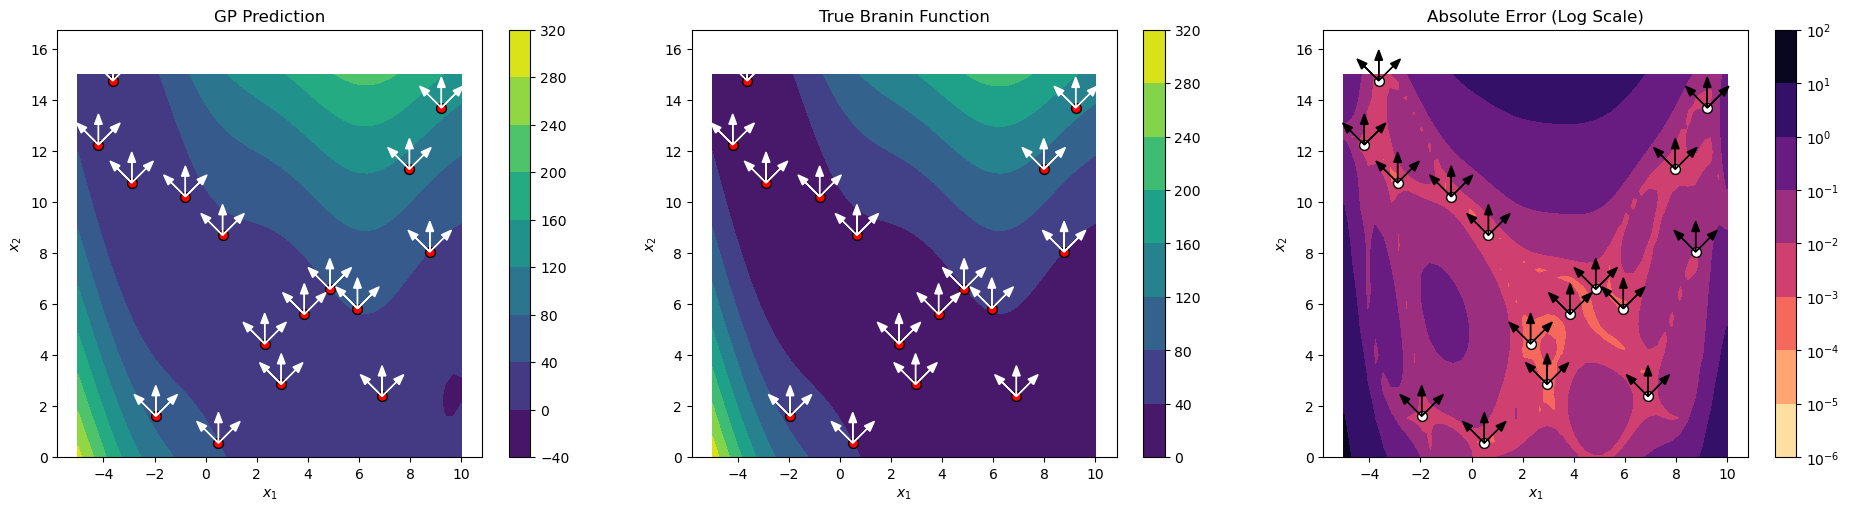

Final NRMSE: 0.003622


In [8]:
training_data = generate_training_data()
gp_model, params = train_model(training_data)
results = evaluate_model(gp_model, params)
visualize_results(training_data, results)
print(f"Final NRMSE: {results['nrmse']:.6f}")